# QuantumCircuit.jl Flux Tunable Transmon Tutorial

**Audience**
- QuantumCircuit.jl에서 flux-tunable transmon workflow를 처음 정리하는 Julia 사용자

**Prerequisites**
- 기본 Julia 문법
- `CompositeSystem`, `simulate_sweep`, `evolve` 같은 top-level API 이름을 읽을 수 있는 정도의 배경
- reduced flux와 transmon에 대한 아주 기본적인 물리 직관

**Learning Goals**
- `TunableTransmon`의 핵심 parameter와 unit convention을 읽을 수 있습니다.
- `CircuitHamiltonianSpec(...)` 기반 exact charge-basis sweep을 먼저 실행하고 해석할 수 있습니다.
- 현재 코드가 쓰는 circuit Hamiltonian과 effective Duffing Hamiltonian 수식을 연결해서 읽을 수 있습니다.
- exact circuit flux dynamics와 effective/nonadiabatic flux dynamics를 각각 실행하고 차이를 비교할 수 있습니다.


## Outline

1. 환경을 활성화하고 plotting helper를 준비합니다.
2. `TunableTransmon` parameter와 단위 규약을 빠르게 확인합니다.
3. 현재 코드의 circuit Hamiltonian 수식을 읽고 exact local dimension을 확인합니다.
4. exact circuit sweep을 먼저 실행해서 flux dependence를 baseline으로 잡습니다.
5. effective Duffing approximation과 `EJ_eff(Phi, d)` 직관을 도입하고 exact 결과와 비교합니다.
6. exact circuit-mode flux dynamics를 실행합니다.
7. effective/nonadiabatic flux dynamics를 실행합니다.
8. 두 dynamics path를 같은 observable로 비교하고 pitfalls를 정리합니다.


In [2]:
using Pkg

function find_repo_root(start::AbstractString)
    candidates = [
        normpath(start),
        normpath(joinpath(start, "..")),
        normpath(joinpath(start, "..", "..")),
    ]

    for candidate in unique(candidates)
        project_toml = joinpath(candidate, "Project.toml")
        if isfile(project_toml)
            content = read(project_toml, String)
            occursin("QuantumCircuit", content) && return candidate
        end
    end

    error("Could not find the QuantumCircuit.jl project root. Start Jupyter from the repository or open the notebook from inside it.")
end

project_root = find_repo_root(pwd())
Pkg.activate(project_root)
Pkg.instantiate()

using QuantumCircuit

include(joinpath(project_root, "output", "jupyter-notebook", "makie_helpers.jl"))
activate_notebook_theme!()

nothing


  Activating project at `~/Research/20_Projects/QuantumCircuit.jl`


## Step 1 - `TunableTransmon` parameter를 읽는 기준

이 tutorial은 먼저 exact circuit path를 baseline으로 잡습니다. 장치는 비교적 transmon-like한 한 개의 tunable transmon만 씁니다.

**Unit convention**
- `EJmax`, `EC`, transition frequency, drive frequency는 모두 같은 frequency unit을 씁니다.
- 여기서는 기존 notebook과 맞춰 `GHz`라고 읽겠습니다.
- `flux`는 reduced flux `Phi/Phi0`이고 무차원입니다.
- `asymmetry`는 SQUID junction 비대칭을 요약하는 무차원 parameter입니다.
- `ncut`은 effective Duffing workflow에서 쓰는 local truncation size입니다.
- `charge_cutoff`는 exact circuit mode에서 charge basis를 `-N:N`까지 자르는 cutoff입니다.


In [3]:
tq = TunableTransmon(
    :q;
    EJmax = 14.0,
    EC = 14.0 / 70,
    flux = 0.0,
    asymmetry = 0.2,
    ng = 0.0,
    ncut = 10,
)

sys = CompositeSystem(tq)

(
    subsystem_names = subsystem_names(sys),
    EJmax = tq.EJmax,
    EC = tq.EC,
    parked_flux = tq.flux,
    asymmetry = tq.asymmetry,
    ng = tq.ng,
    effective_ncut = tq.ncut,
)


(subsystem_names = [:q], EJmax = 14.0, EC = 0.2, parked_flux = 0.0, asymmetry = 0.2, ng = 0.0, effective_ncut = 10)

## Step 2 - 현재 코드의 circuit Hamiltonian

`CircuitHamiltonianSpec(charge_cutoff = N)`를 쓰면 tunable transmon은 charge basis `n in {-N, ..., N}` 위에서 exact local Hamiltonian으로 들어갑니다. 즉 local dimension은 `2N + 1`입니다.

현재 `Model.jl`에서 tunable transmon에 쓰는 local Hamiltonian은 아래 식입니다.

$$
\hat H_{\mathrm{circ}}(\Phi)
= 4 E_C (\hat n - n_g I)^2
- E_{J,\max} \cos(\pi \Phi) \, \cos \hat\phi
- E_{J,\max} d \, \sin(\pi \Phi) \, \sin \hat\phi
$$

여기서
- `Phi`는 reduced flux
- `d`는 `asymmetry`
- `n_g`는 offset charge
- `cosphi` / `sinphi` operator는 charge basis 위에서 직접 구성됩니다.

flux control을 붙이면 코드가 base flux에서의 Hamiltonian 위에 time-dependent correction을 더합니다.
`J_c(Phi) = EJmax * cospi(Phi)`, `J_s(Phi) = EJmax * d * sinpi(Phi)`라고 두면

$$
\hat H(t) = \hat H_{\mathrm{circ}}(\Phi_0)
- \left(J_c(\Phi(t)) - J_c(\Phi_0)\right) \cos \hat\phi
- \left(J_s(\Phi(t)) - J_s(\Phi_0)\right) \sin \hat\phi
$$

로 구현되어 있습니다. 아래 셀에서 exact model dimension과 Hamiltonian object 크기를 먼저 확인합니다.


In [4]:
circuit_spec = CircuitHamiltonianSpec(charge_cutoff = 10)
circuit_model = build_model(sys; hamiltonian_spec = circuit_spec)
circuit_H = hamiltonian(circuit_model)

(
    charge_cutoff = circuit_spec.charge_cutoff,
    circuit_dimensions = circuit_model.dimensions,
    hamiltonian_size = size(circuit_H.data),
    hamiltonian_type = typeof(circuit_H),
)


(charge_cutoff = 10, circuit_dimensions = Dict(:q => 21), hamiltonian_size = (21, 21), hamiltonian_type = QuantumToolbox.QuantumObject{QuantumToolbox.Operator, QuantumToolbox.ProductDimensions{1, 1, Tuple{QuantumToolbox.HilbertSpace}, Tuple{QuantumToolbox.HilbertSpace}}, SparseArrays.SparseMatrixCSC{ComplexF64, Int64}})

## Step 3 - exact circuit sweep을 먼저 실행하기

이제 같은 장치를 exact circuit mode로 flux sweep합니다. 이 tutorial에서는 이 결과를 **baseline**으로 읽습니다.

즉 이후에 나오는 effective sweep은 “정답 교체”가 아니라 “빠른 근사와 직관”으로 읽는 것이 맞습니다. figure는 low-lying spectrum과 derived metric을 같이 보여줍니다.


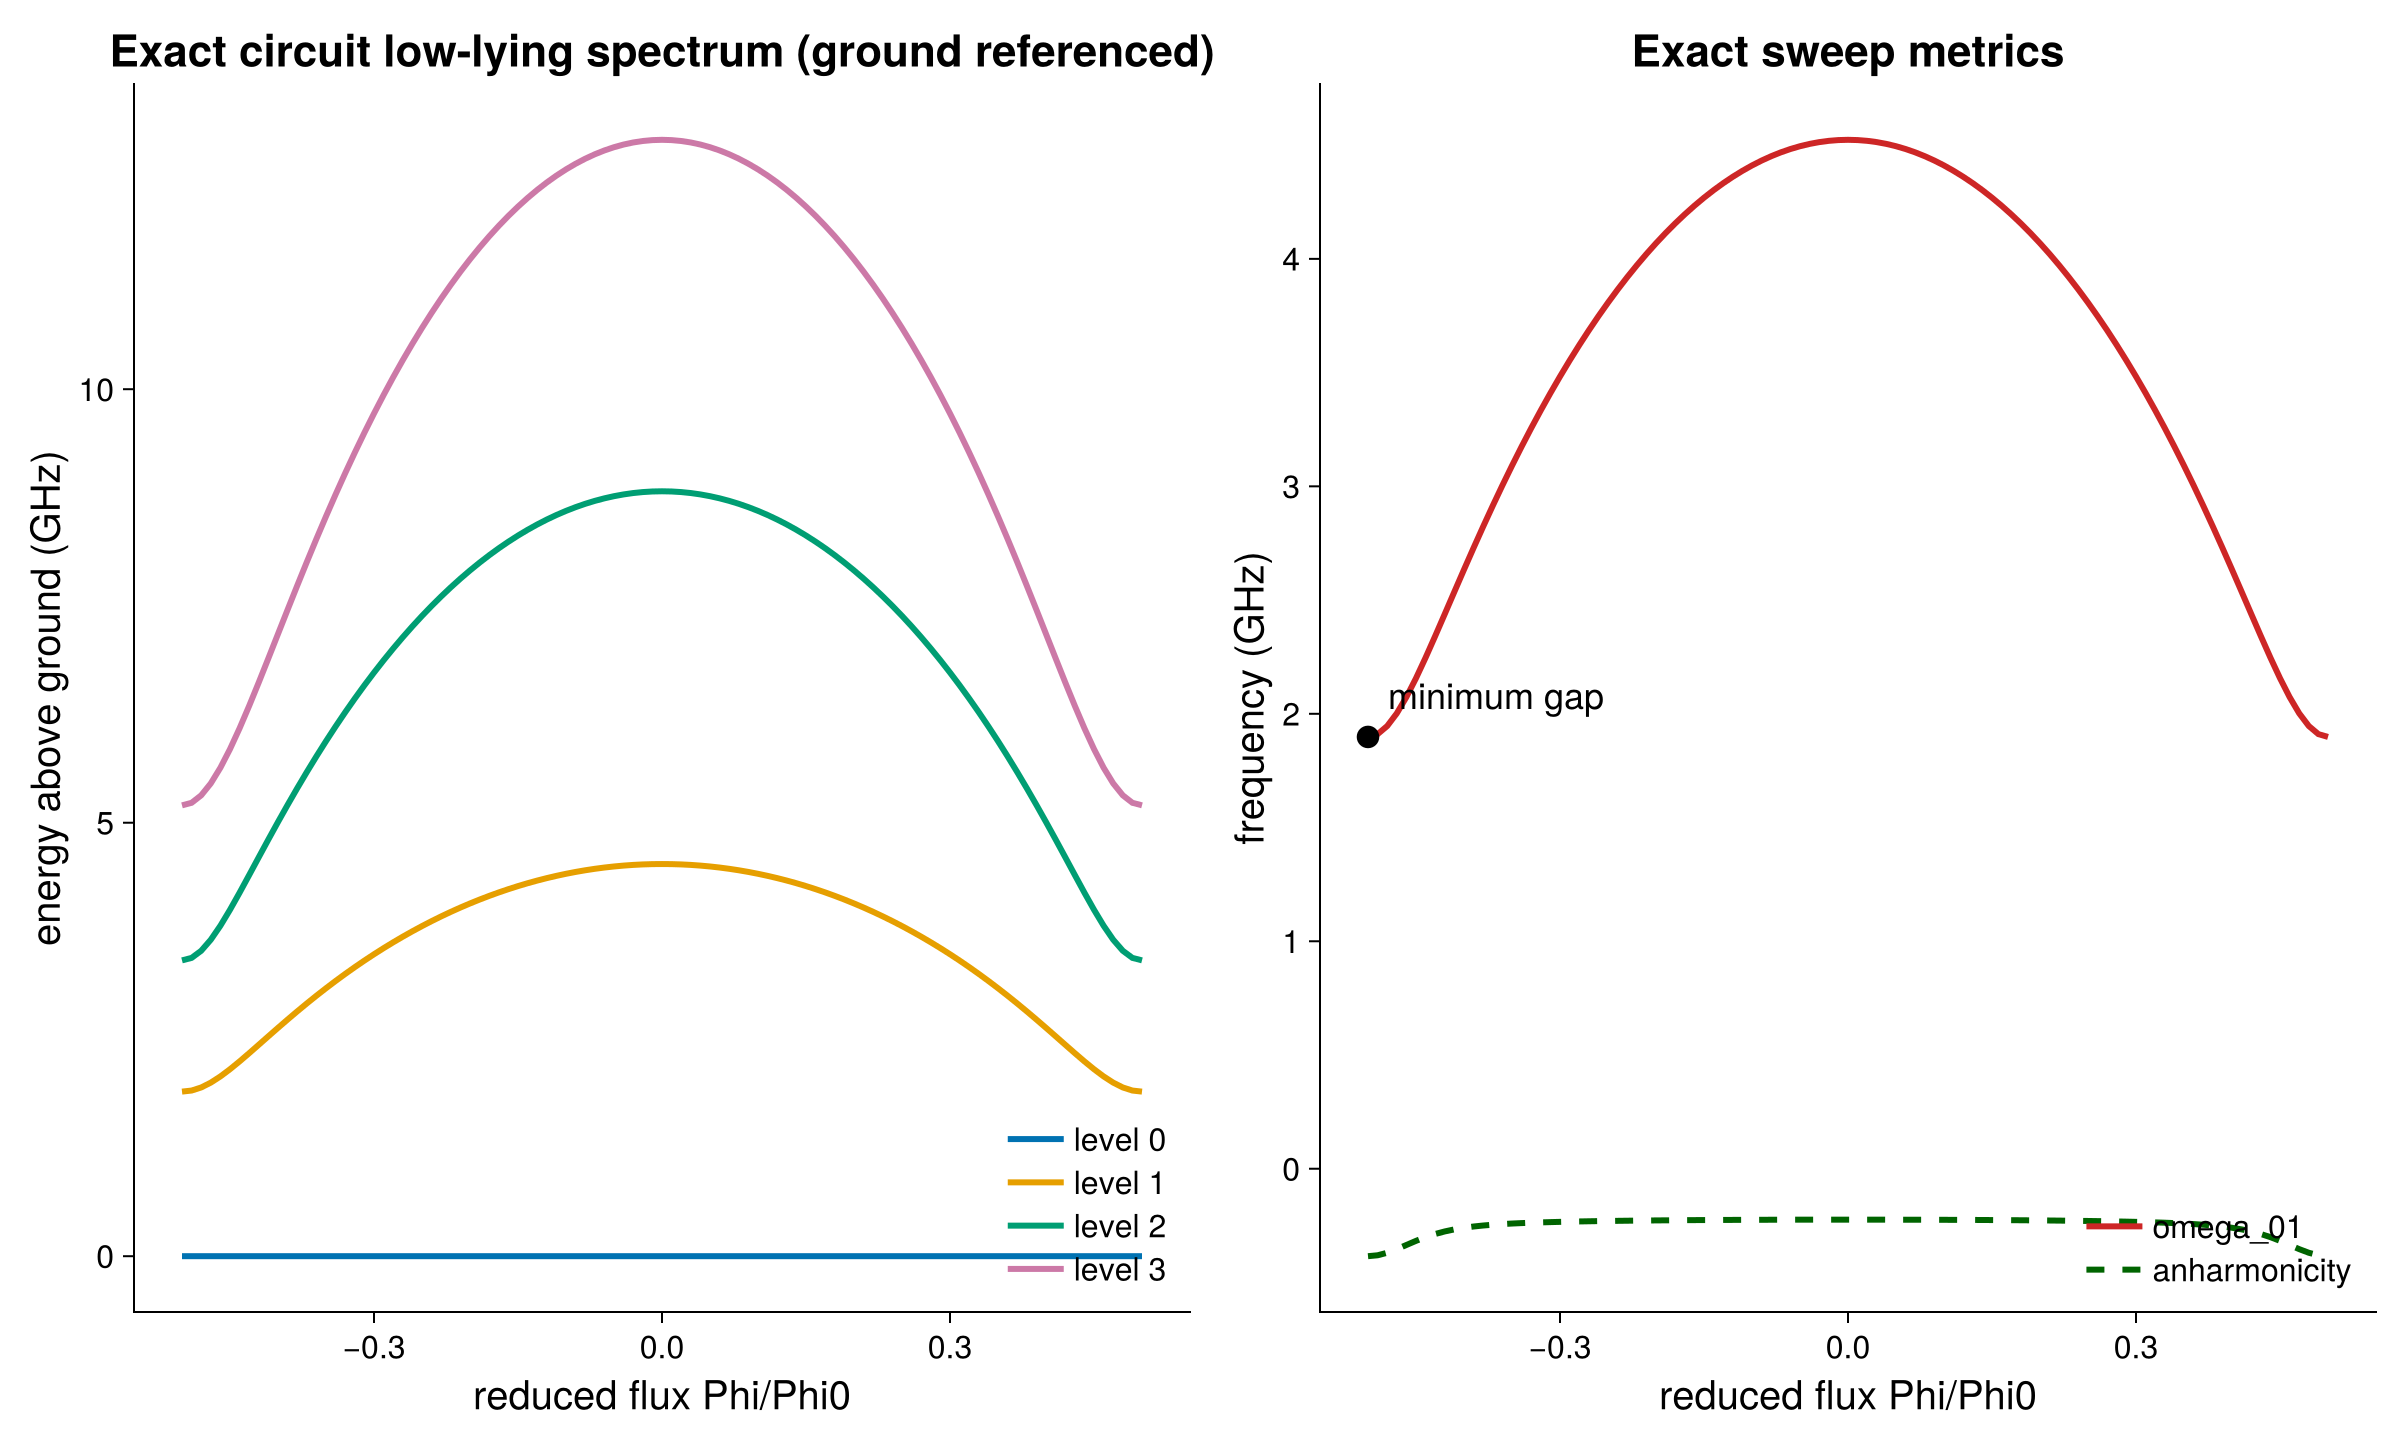

(exact_omega_01 = [1.898257582453805, 1.9105483949565993, 1.9461987508317453, 2.0019566430147315, 2.073508228610368, 2.1564555239868985, 2.246946016292575, 2.34191544272918, 2.4390748861678557, 2.536783720216004  …  2.536783720216004, 2.4390748861678557, 2.34191544272918, 2.246946016292575, 2.1564555239868985, 2.073508228610368, 2.0019566430147315, 1.9461987508317453, 1.9105483949565993, 1.898257582453805], exact_anharmonicity = [-0.38444203487262807, -0.38048295866423754, -0.36943217276096996, -0.3534430480941919, -0.33520363569892475, -0.3171056057016406, -0.30074801648722693, -0.2868724825686595, -0.27557736267256994, -0.2666005261295892  …  -0.2666005261295892, -0.27557736267256994, -0.2868724825686595, -0.30074801648722693, -0.3171056057016406, -0.33520363569892475, -0.3534430480941919, -0.36943217276096996, -0.38048295866423754, -0.38444203487262807], minimum_gap = (gap = 1.898257582453805, sweep_value = -0.5, index = 1, level_pair = (1, 2)))

In [5]:
exact_flux_values = range(-0.5, 0.5, length=101)
exact_sweep = SweepSpec(:q, :flux, exact_flux_values; levels = 4)
exact_result = simulate_sweep(sys, exact_sweep; hamiltonian_spec = circuit_spec)

exact_w01 = transition_curve(exact_result)
exact_alpha = anharmonicity_curve(exact_result)
exact_gap = minimum_gap(exact_result)
exact_energies = reduce(hcat, [spec.energies for spec in exact_result.spectra])
exact_relative_energies = exact_energies .- exact_energies[1:1, :]

exact_overview_fig = Figure(size = (1200, 720))
ax_levels = Axis(
    exact_overview_fig[1, 1];
    title = "Exact circuit low-lying spectrum (ground referenced)",
    xlabel = "reduced flux Phi/Phi0",
    ylabel = "energy above ground (GHz)",
)
for level_index in axes(exact_relative_energies, 1)
    lines!(
        ax_levels,
        exact_flux_values,
        exact_relative_energies[level_index, :];
        label = "level $(level_index - 1)",
    )
end
axislegend(ax_levels; position = :rb)

ax_metrics = Axis(
    exact_overview_fig[1, 2];
    title = "Exact sweep metrics",
    xlabel = "reduced flux Phi/Phi0",
    ylabel = "frequency (GHz)",
)
lines!(ax_metrics, exact_flux_values, exact_w01.data; label = "omega_01", color = :firebrick3)
lines!(ax_metrics, exact_flux_values, exact_alpha.data; label = "anharmonicity", color = :darkgreen, linestyle = :dash)
scatter!(ax_metrics, [exact_gap.sweep_value], [exact_gap.gap]; color = :black, markersize = 16)
text!(ax_metrics, exact_gap.sweep_value, exact_gap.gap; text = "minimum gap", offset = (10, 10))
axislegend(ax_metrics; position = :rb)

display(exact_overview_fig)

(
    exact_omega_01 = exact_w01.data,
    exact_anharmonicity = exact_alpha.data,
    minimum_gap = exact_gap,
)


## Step 4 - effective Duffing approximation과 Hamiltonian 비교

current effective path는 exact charge-basis Hamiltonian을 직접 diagonalize하지 않고, flux-dependent `EJ_eff`를 먼저 만든 뒤 Duffing Hamiltonian으로 바꿉니다.

$$
E_{J,\mathrm{eff}}(\Phi, d)
= E_{J,\max} \sqrt{\cos^2(\pi \Phi) + d^2 \sin^2(\pi \Phi)}
$$

그리고 static effective transmon은

$$
\omega(\Phi) = \sqrt{8 E_{J,\mathrm{eff}}(\Phi, d) E_C} - E_C,
\qquad
\alpha = -E_C
$$

$$
\hat H_{\mathrm{eff}}(\Phi)
= \omega(\Phi) \, \hat n
+ \frac{\alpha}{2} \, \hat n (\hat n - I)
$$

를 사용합니다. 아래에서는 normalized `EJ_eff` intuition, exact vs effective `omega_01`, 그리고 residual을 같이 봅니다.


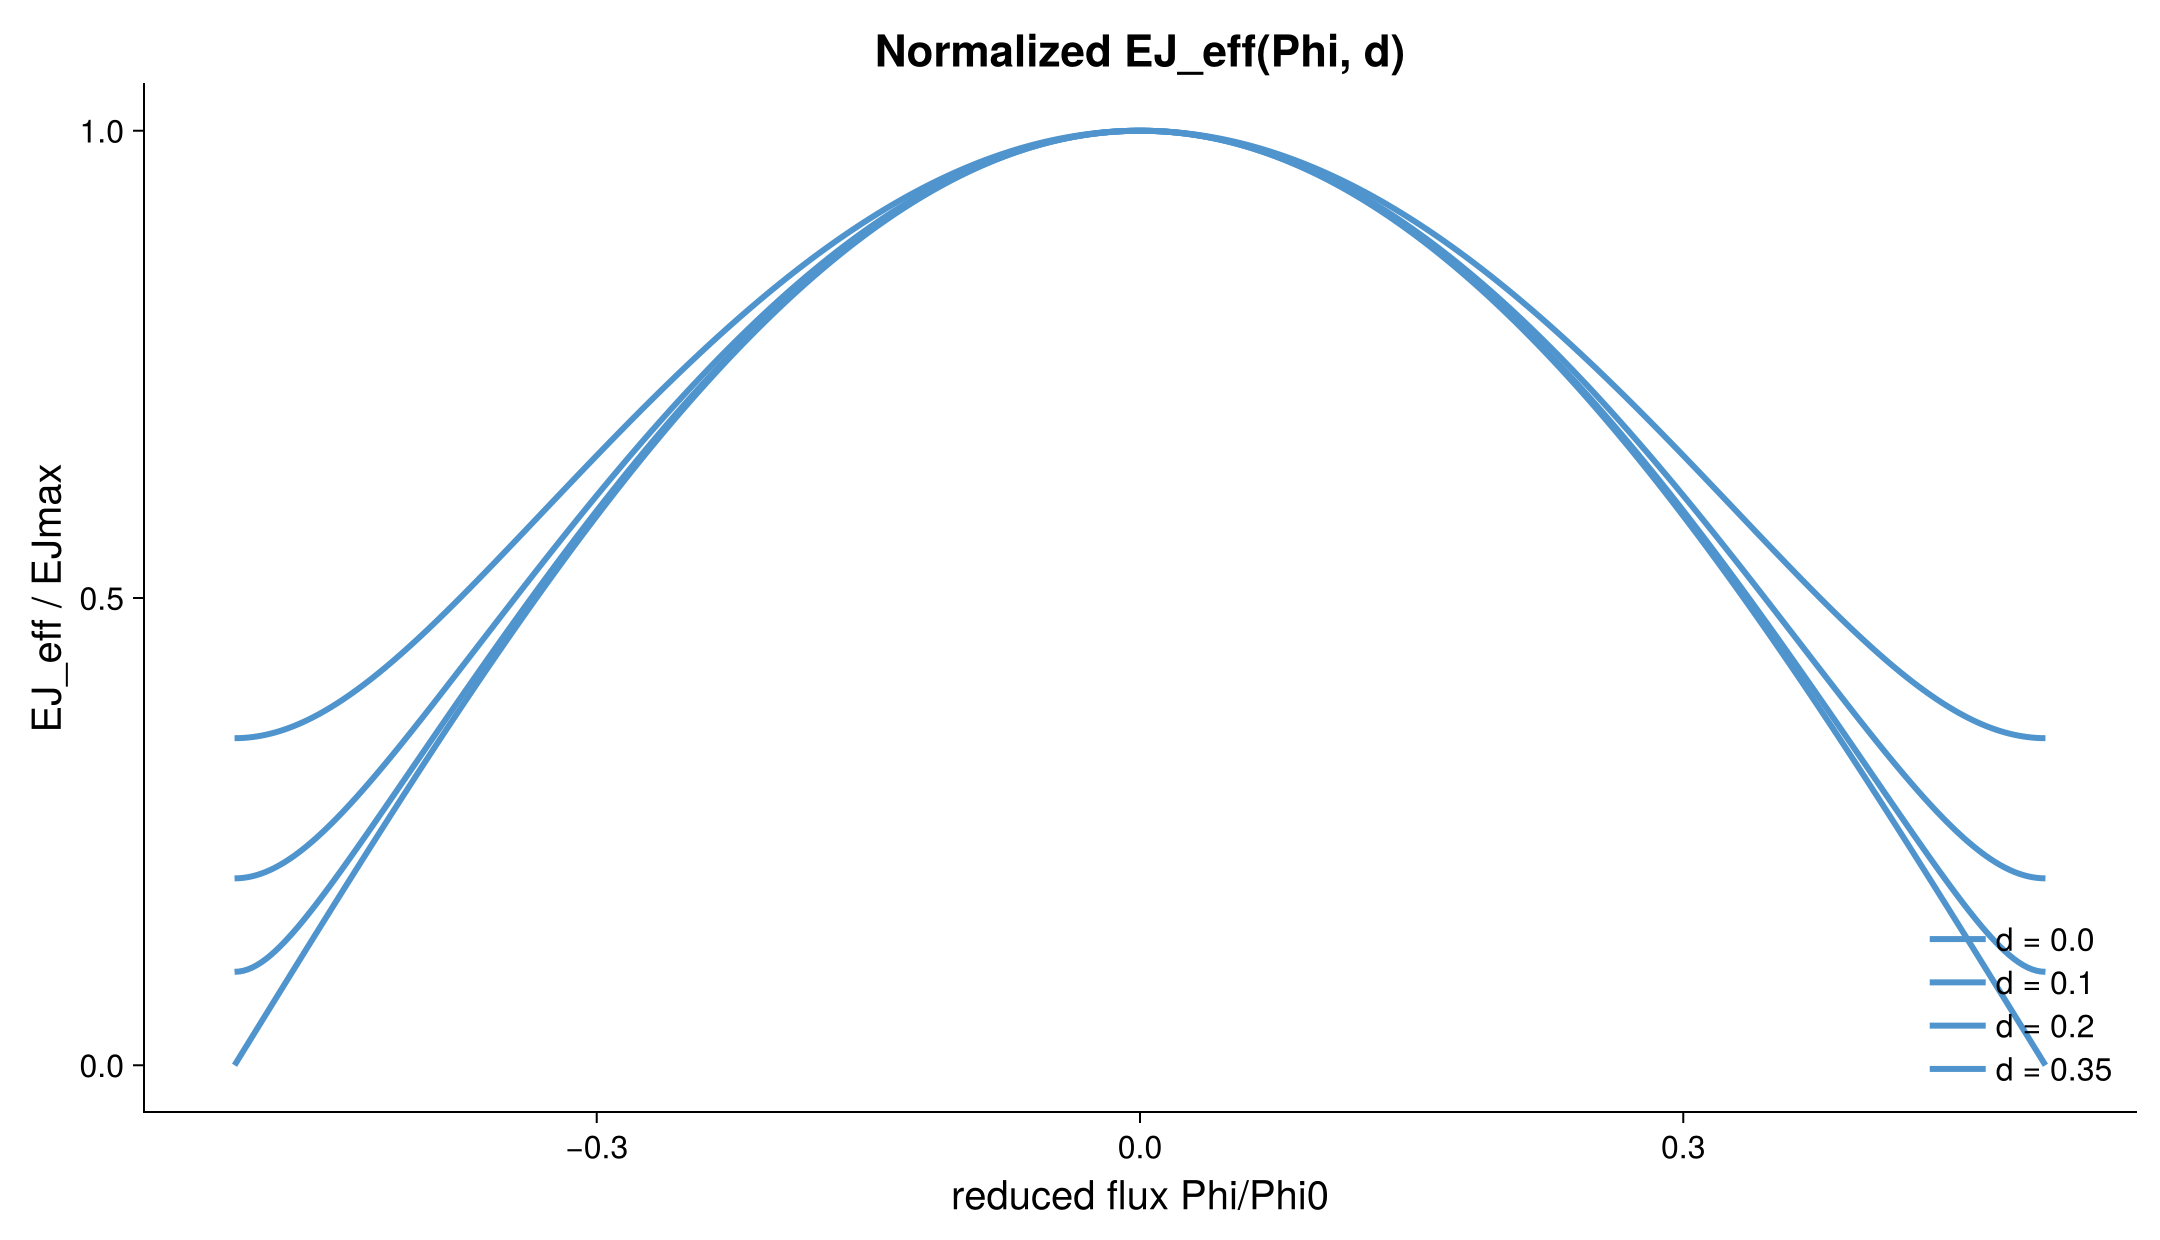

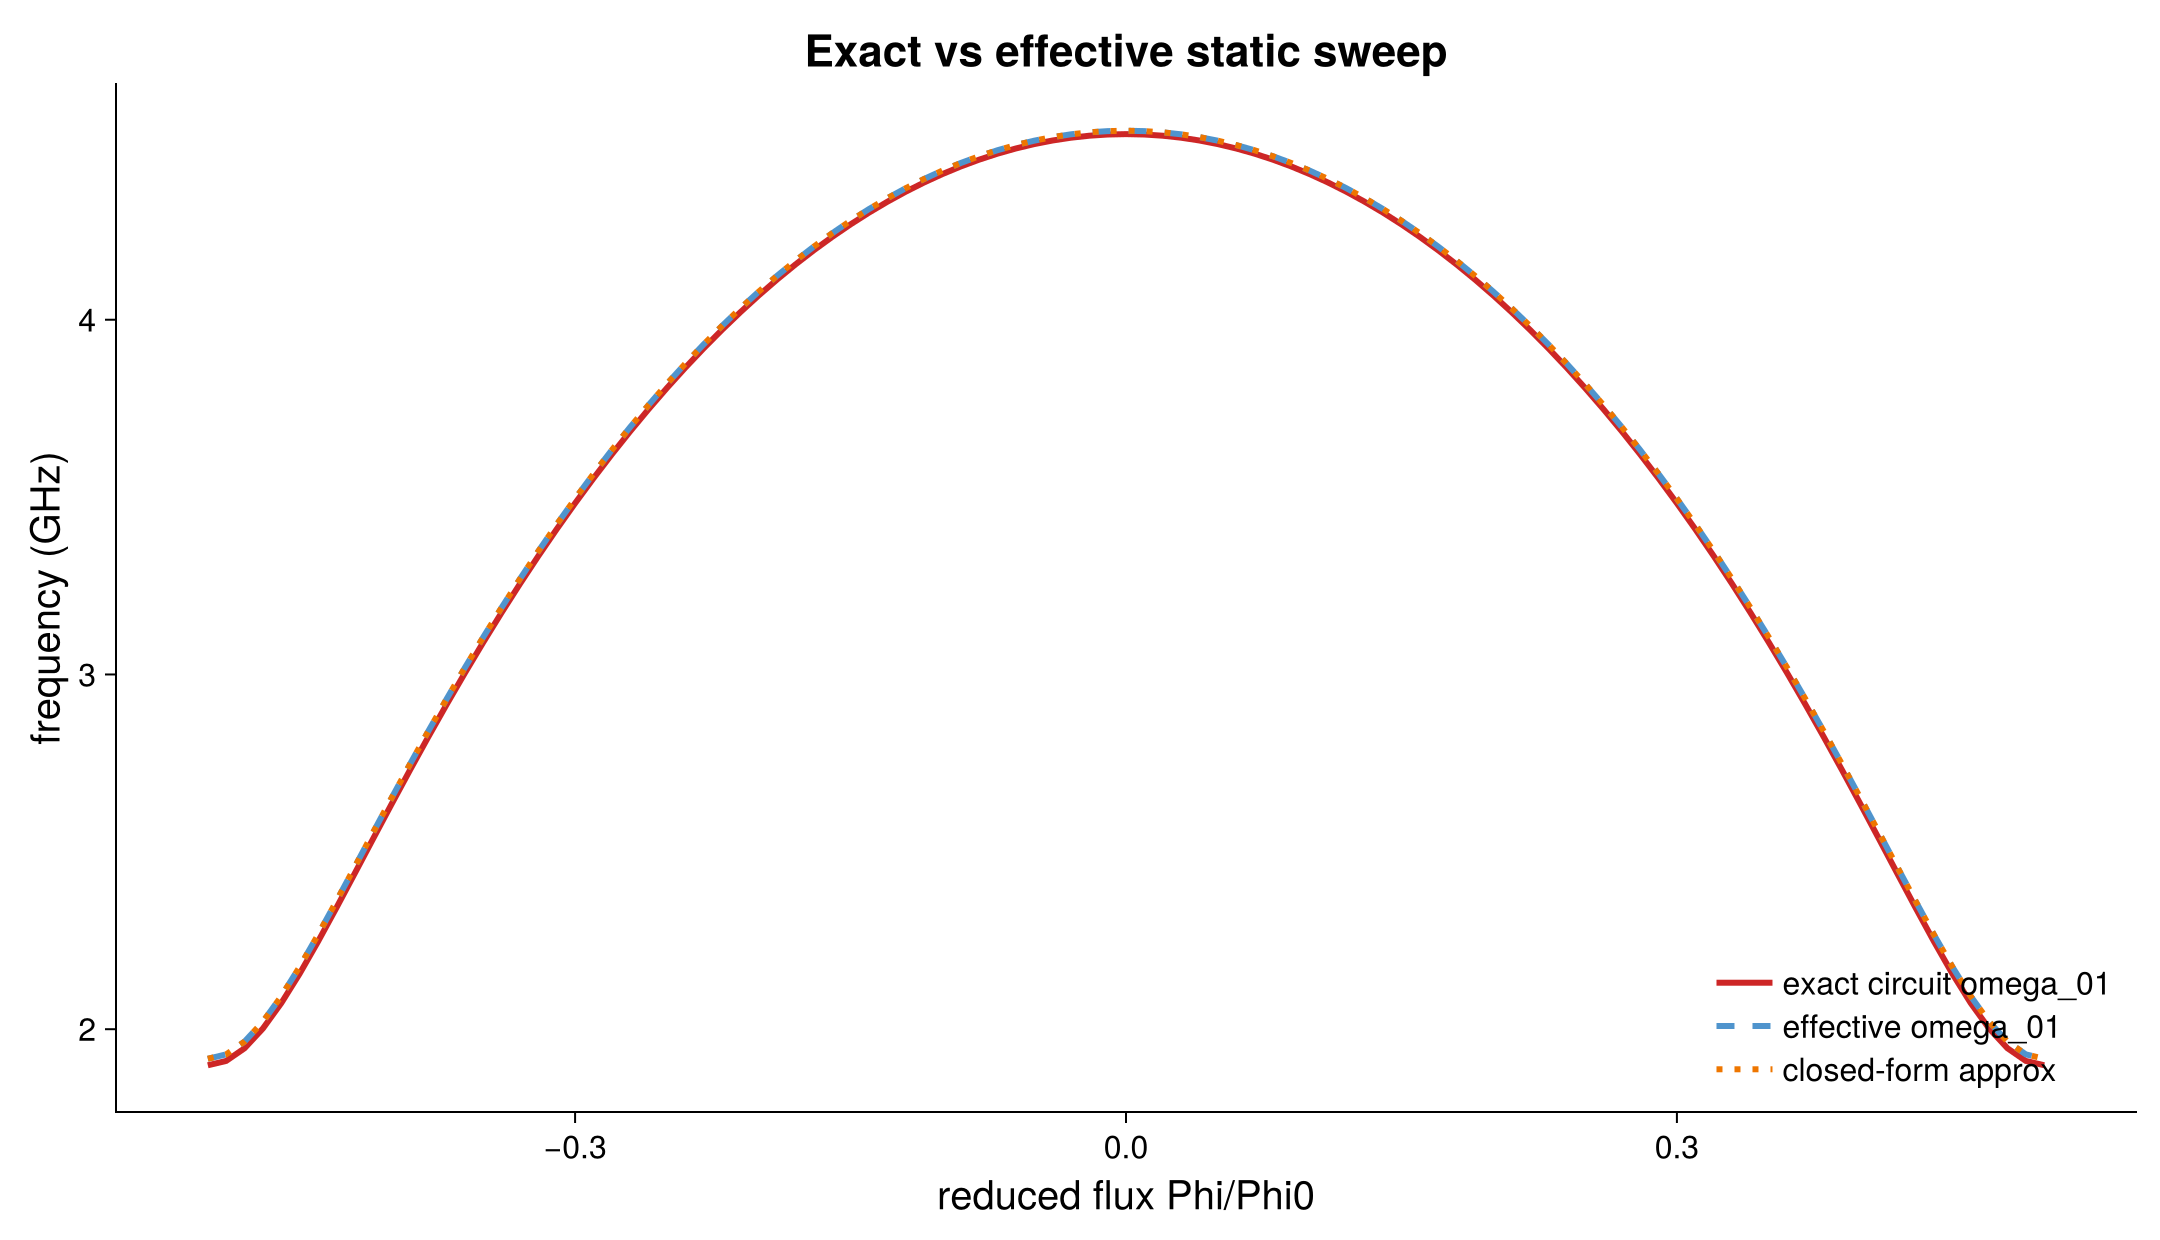

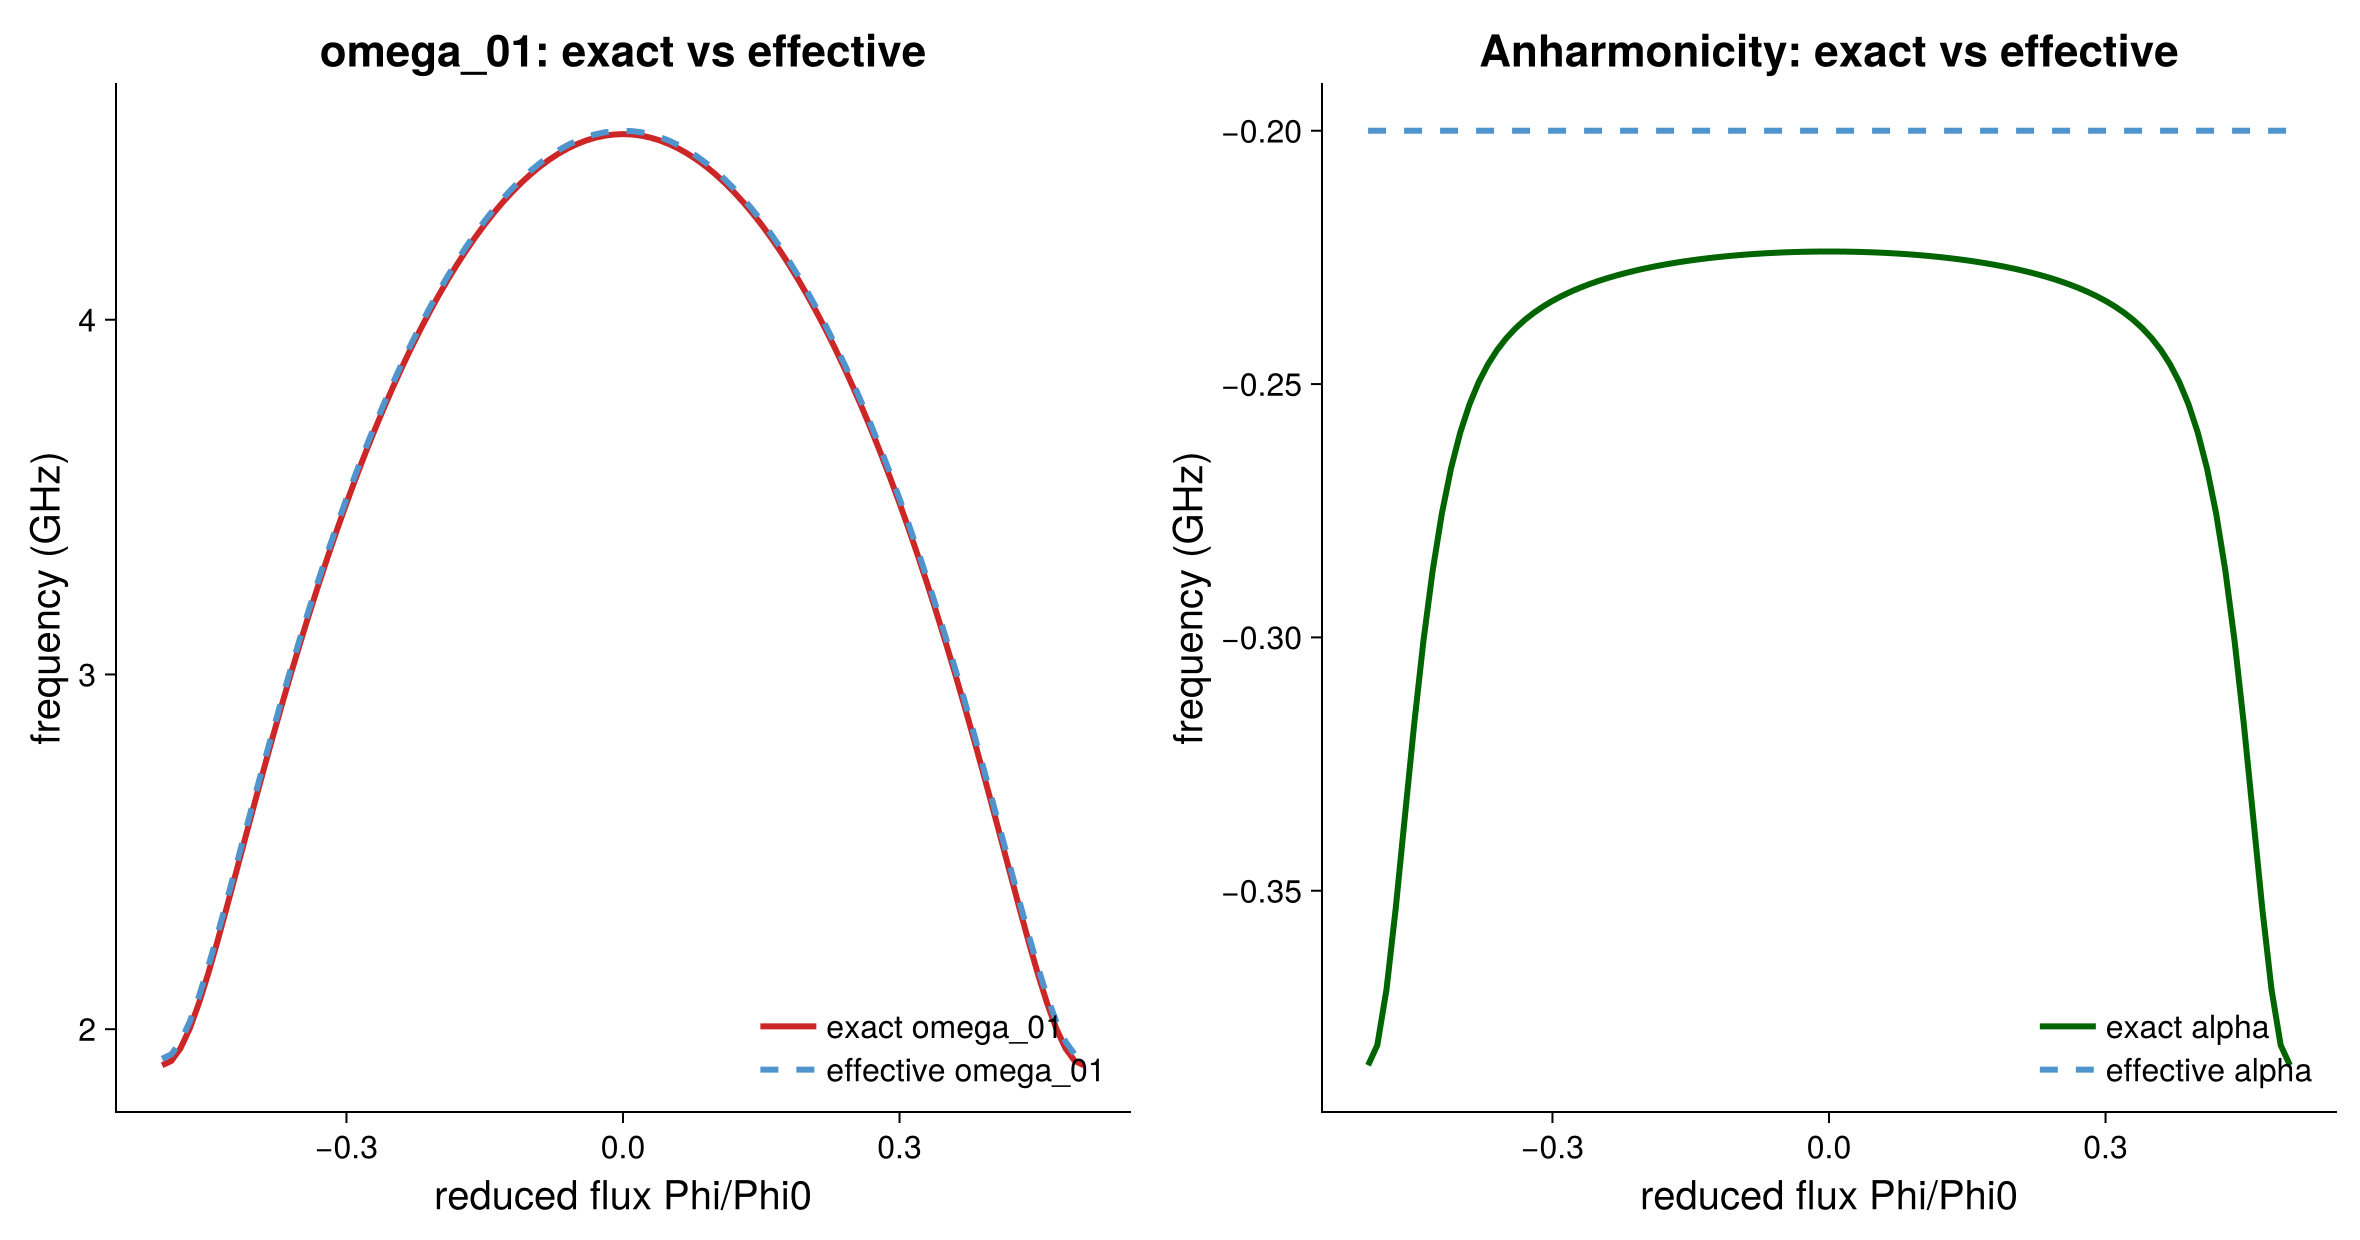

(exact_omega_01 = [1.898257582453805, 1.9105483949565993, 1.9461987508317453, 2.0019566430147315, 2.073508228610368, 2.1564555239868985, 2.246946016292575, 2.34191544272918, 2.4390748861678557, 2.536783720216004  …  2.536783720216004, 2.4390748861678557, 2.34191544272918, 2.246946016292575, 2.1564555239868985, 2.073508228610368, 2.0019566430147315, 1.9461987508317453, 1.9105483949565993, 1.898257582453805], effective_omega_01 = [1.9166010488516727, 1.9290211852479586, 1.9649865729868081, 2.0210799353436846, 2.0928342208265436, 2.1757746964895546, 2.266048509668969, 2.3606350977908472, 2.4573018134007927, 2.55445860742167  …  2.55445860742167, 2.4573018134007927, 2.3606350977908472, 2.266048509668969, 2.1757746964895546, 2.0928342208265436, 2.0210799353436846, 1.9649865729868081, 1.9290211852479586, 1.9166010488516727], static_residual = [-0.018343466397867658, -0.018472790291359287, -0.018787822155062806, -0.019123292328953045, -0.019325992216175703, -0.019319172502656023, -0.019102493

In [6]:
effective_josephson_energy(EJmax, flux, d) =
    EJmax * sqrt(cospi(flux)^2 + (d * sinpi(flux))^2)

approx_transmon_f01(EJ_eff, EC) = sqrt(8 * EJ_eff * EC) - EC

effective_result = simulate_sweep(sys, exact_sweep)
effective_w01 = transition_curve(effective_result)
effective_alpha = anharmonicity_curve(effective_result)
static_residual = exact_w01.data .- effective_w01.data

flux_grid = collect(range(-0.5, 0.5; length = 401))
asymmetry_values = [0.0, 0.10, 0.20, 0.35]
normalized_curves = [
    (
        x = flux_grid,
        y = [effective_josephson_energy(tq.EJmax, flux, d) / tq.EJmax for flux in flux_grid],
        label = "d = $(round(d, digits = 2))",
    ) for d in asymmetry_values
]
normalized_ej_fig = line_figure(
    normalized_curves;
    title = "Normalized EJ_eff(Phi, d)",
    xlabel = "reduced flux Phi/Phi0",
    ylabel = "EJ_eff / EJmax",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
)

static_compare_fig = line_figure(
    [
        (x = exact_flux_values, y = exact_w01.data, label = "exact circuit omega_01", color = :firebrick3),
        (x = exact_flux_values, y = effective_w01.data, label = "effective omega_01", color = :steelblue3, linestyle = :dash),
        (x = exact_flux_values, y = [approx_transmon_f01(effective_josephson_energy(tq.EJmax, flux, tq.asymmetry), tq.EC) for flux in exact_flux_values], label = "closed-form approx", color = :darkorange2, linestyle = :dot),
    ];
    title = "Exact vs effective static sweep",
    xlabel = "reduced flux Phi/Phi0",
    ylabel = "frequency (GHz)",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
)

static_residual_fig = Figure(size = (1180, 620))
ax_residual = Axis(
    static_residual_fig[1, 1];
    title = "omega_01: exact vs effective",
    xlabel = "reduced flux Phi/Phi0",
    ylabel = "frequency (GHz)",
)
lines!(ax_residual, exact_flux_values, exact_w01.data; color = :firebrick3, label = "exact omega_01")
lines!(ax_residual, exact_flux_values, effective_w01.data; color = :steelblue3, linestyle = :dash, label = "effective omega_01")
axislegend(ax_residual; position = :rb)

ax_alpha = Axis(
    static_residual_fig[1, 2];
    title = "Anharmonicity: exact vs effective",
    xlabel = "reduced flux Phi/Phi0",
    ylabel = "frequency (GHz)",
)
lines!(ax_alpha, exact_flux_values, exact_alpha.data; color = :darkgreen, label = "exact alpha")
lines!(ax_alpha, exact_flux_values, effective_alpha.data; color = :steelblue3, label = "effective alpha", linestyle = :dash)
axislegend(ax_alpha; position = :rb)

display(normalized_ej_fig)
display(static_compare_fig)
display(static_residual_fig)

(
    exact_omega_01 = exact_w01.data,
    effective_omega_01 = effective_w01.data,
    static_residual = static_residual,
)


## Step 5 - exact circuit-mode flux dynamics

dynamic example도 exact path를 먼저 봅니다. 여기서는 parked flux를 `0.15`로 옮기고, 하나의 sinusoidal flux waveform을 걸어 charge-basis time evolution을 실행합니다.

waveform은

$$
\Phi(t) = \Phi_0 + \delta \sin(\omega_f t)
$$

로 두고, exact circuit path에서는 앞에서 본

$$
\hat H(t) = \hat H_{\mathrm{circ}}(\Phi_0)
- \left(J_c(\Phi(t)) - J_c(\Phi_0)\right) \cos \hat\phi
- \left(J_s(\Phi(t)) - J_s(\Phi_0)\right) \sin \hat\phi
$$

를 그대로 적분합니다. line plot은 대표 observable을, heatmap은 low-lying local level population flow를 보여줍니다.


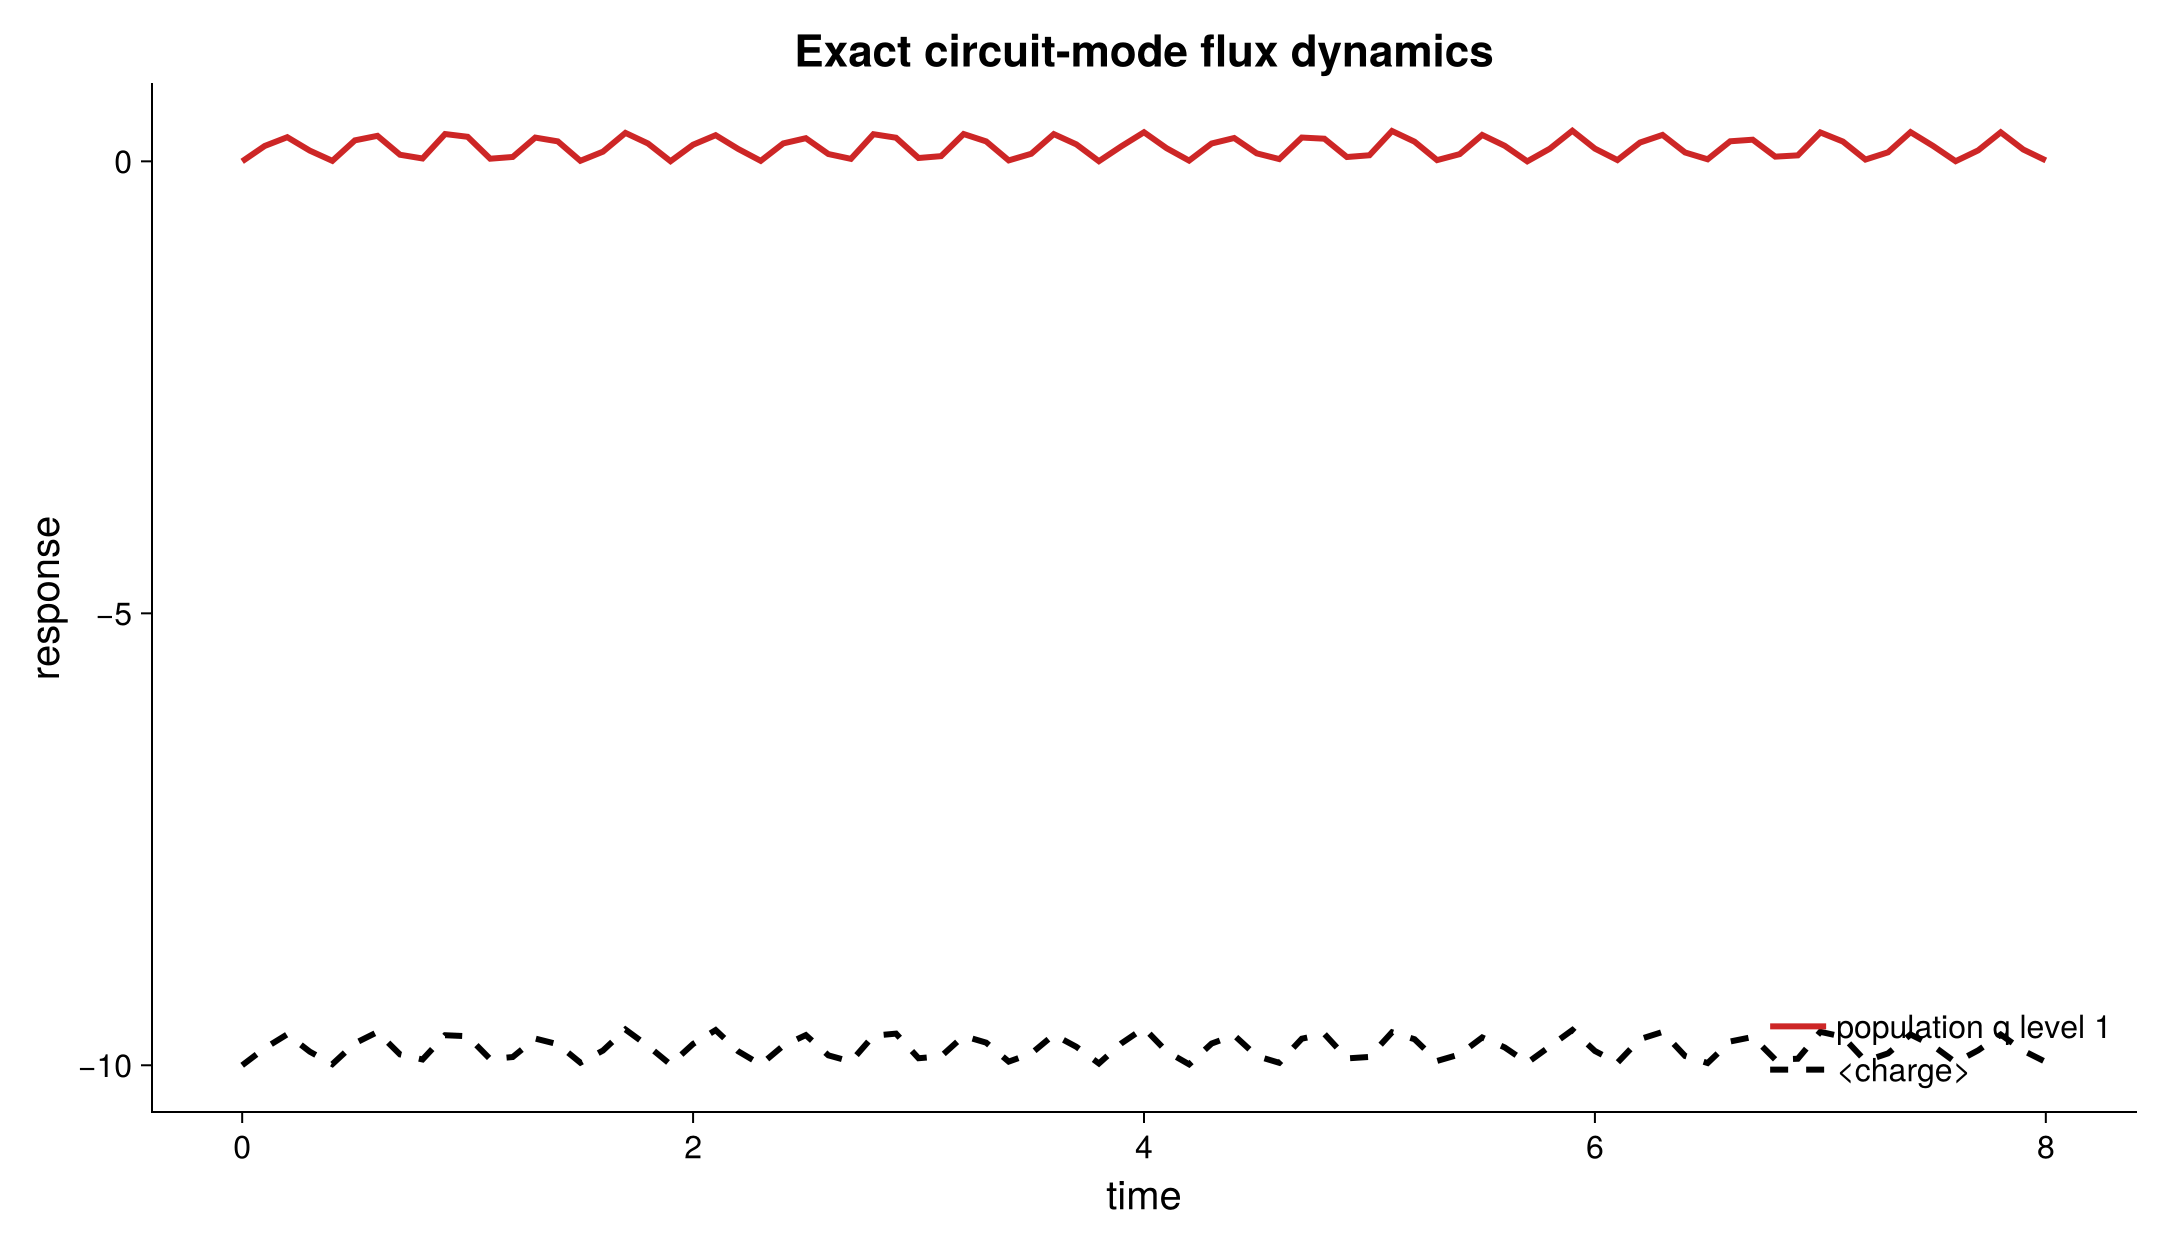

LoadError: Error in conversion pipeline. xs and ys should have size ni+1, nj+1. Found: xs: 81, ys: 4, ni: 4, nj: 81

In [7]:
dynamics_tq = TunableTransmon(
    :q;
    EJmax = tq.EJmax,
    EC = tq.EC,
    flux = 0.25,
    asymmetry = tq.asymmetry,
    ng = tq.ng,
    ncut = tq.ncut,
)
dynamics_sys = CompositeSystem(dynamics_tq)

flux_drive = FluxControl(
    :flux_drive,
    :q,
    (p, t) -> p.delta * sin(p.omega_f * t);
    derivative = (p, t) -> p.delta * p.omega_f * cos(p.omega_f * t),
)

tlist = collect(range(0.0, 8.0; length = 81))
circuit_initial = basis_state(dynamics_sys; hamiltonian_spec = circuit_spec, q = 0)
circuit_dynamics = evolve(
    dynamics_sys,
    circuit_initial,
    tlist;
    hamiltonian_spec = circuit_spec,
    flux_controls = [flux_drive],
    observables = [ObservableSpec(:charge, :q, :charge)],
    params = (; delta = 0.04, omega_f = 6.0),
)

circuit_population_levels = collect(0:3)
circuit_population_matrix = hcat([
    real.(population_trace(circuit_dynamics, :q, level).values) for level in circuit_population_levels
]...)

circuit_p1 = population_trace(circuit_dynamics, :q, 1)
circuit_charge = observable_trace(circuit_dynamics, :charge)

circuit_dynamics_fig = line_figure(
    [
        (x = circuit_p1.times, y = circuit_p1.values, label = "population q level 1", color = :firebrick3),
        (x = circuit_charge.times, y = real.(circuit_charge.values), label = "<charge>", color = :black, linestyle = :dash),
    ];
    title = "Exact circuit-mode flux dynamics",
    xlabel = "time",
    ylabel = "response",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
)

circuit_population_heatmap = heatmap_figure(
    tlist,
    circuit_population_levels,
    circuit_population_matrix;
    title = "Exact-circuit population flow across local levels",
    xlabel = "time",
    ylabel = "local level",
    colorlabel = "population",
    size = NOTEBOOK_WIDE,
    colormap = :viridis,
    colorrange = (0.0, 1.0),
)

display(circuit_dynamics_fig)
display(circuit_population_heatmap)

(
    max_exact_level1_population = maximum(circuit_p1.values),
    first_exact_population_values = circuit_p1.values[1:5],
    first_exact_charge_values = real.(circuit_charge.values[1:5]),
)


## Step 6 - effective / nonadiabatic flux dynamics

같은 waveform을 effective path에서도 돌릴 수 있지만, static Duffing Hamiltonian만으로는 충분하지 않습니다. 코드에서는 `EffectiveHamiltonianSpec(NonadiabaticDuffingEffectiveMethod())`를 써서 flux derivative까지 포함한 correction term을 붙입니다.

구현된 형태는 개념적으로

$$
\hat H_{\mathrm{nad}}(t)
= \hat H_{\mathrm{eff}}(\Phi_0)
+ \Delta \omega(t) \, \hat n
+ c_y(t) \, \hat y
+ c_{\mathrm{pair}}(t) \, i (\hat a^{\dagger 2} - \hat a^2)
$$

입니다. 여기서
- `Delta omega(t)`는 flux-modulated local frequency shift
- `c_y(t)`와 `c_pair(t)`는 `dPhi/dt`에 비례하는 nonadiabatic correction
- 그래서 `FluxControl(...; derivative = ...)`가 반드시 필요합니다.

현재 구현은 이 path를 **uncoupled single-subsystem system**에서만 지원합니다.


In [ ]:
nonadiabatic_spec = EffectiveHamiltonianSpec(NonadiabaticDuffingEffectiveMethod())
effective_initial = basis_state(dynamics_sys; hamiltonian_spec = nonadiabatic_spec, q = 0)
effective_dynamics = evolve(
    dynamics_sys,
    effective_initial,
    tlist;
    hamiltonian_spec = nonadiabatic_spec,
    flux_controls = [flux_drive],
    observables = [ObservableSpec(:nq, :q, :n)],
    params = (; delta = 0.04, omega_f = 6.0),
)

effective_population_levels = collect(0:3)
effective_population_matrix = hcat([
    real.(population_trace(effective_dynamics, :q, level).values) for level in effective_population_levels
]...)

effective_p1 = population_trace(effective_dynamics, :q, 1)
effective_nq = observable_trace(effective_dynamics, :nq)

effective_dynamics_fig = line_figure(
    [
        (x = effective_p1.times, y = effective_p1.values, label = "population q level 1", color = :steelblue3),
        (x = effective_nq.times, y = real.(effective_nq.values), label = "<n>", color = :darkorange2, linestyle = :dash),
    ];
    title = "Effective nonadiabatic flux dynamics",
    xlabel = "time",
    ylabel = "response",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
)

effective_population_heatmap = heatmap_figure(
    tlist,
    effective_population_levels,
    effective_population_matrix;
    title = "Effective population flow across local levels",
    xlabel = "time",
    ylabel = "local level",
    colorlabel = "population",
    size = NOTEBOOK_WIDE,
    colormap = :viridis,
    colorrange = (0.0, 1.0),
)

display(effective_dynamics_fig)
display(effective_population_heatmap)

(
    max_effective_level1_population = maximum(effective_p1.values),
    first_effective_population_values = effective_p1.values[1:5],
    first_effective_number_values = real.(effective_nq.values[1:5]),
)


## Step 7 - exact baseline과 effective dynamics 비교

여기서는 exact path를 baseline으로 잡고, effective/nonadiabatic path가 어디까지 비슷한 qualitative story를 주는지 봅니다.

같은 `population_trace(..., :q, 1)`를 놓고 보면 shape와 peak size가 꽤 다를 수 있습니다. 이 차이가 바로 “exact charge-basis dynamics를 언제 써야 하는가”를 알려주는 신호입니다.


In [ ]:
population_difference = circuit_p1.values .- effective_p1.values
absolute_difference = abs.(population_difference)

dynamics_comparison_fig = line_figure(
    [
        (x = circuit_p1.times, y = circuit_p1.values, label = "exact circuit p1", color = :firebrick3),
        (x = effective_p1.times, y = effective_p1.values, label = "effective p1", color = :steelblue3, linestyle = :dash),
    ];
    title = "Flux dynamics: exact baseline vs effective approximation",
    xlabel = "time",
    ylabel = "population of level 1",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
)

difference_fig = line_figure(
    [
        (x = circuit_p1.times, y = population_difference, label = "exact - effective", color = :black),
        (x = circuit_p1.times, y = absolute_difference, label = "absolute difference", color = :darkorange2, linestyle = :dash),
    ];
    title = "Population residual between the two dynamics paths",
    xlabel = "time",
    ylabel = "difference",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
)

display(dynamics_comparison_fig)
display(difference_fig)

(
    exact_peak = maximum(circuit_p1.values),
    effective_peak = maximum(effective_p1.values),
    peak_difference = maximum(absolute_difference),
)


## Step 8 - Pitfalls, current limits, and a short exercise

**Pitfalls**
- exact circuit path는 `charge_cutoff`에 따라 결과가 움직입니다. 이 notebook의 `charge_cutoff = 10`은 tutorial용 baseline입니다.
- effective static path는 `alpha = -EC`가 고정이라 exact circuit anharmonicity의 flux dependence를 그대로 담지 못합니다.
- effective/nonadiabatic `FluxControl`은 현재 single-subsystem uncoupled system만 지원합니다.
- asymmetry가 아주 작고 half-flux에 너무 가까워지면 effective path는 더 조심해서 읽어야 합니다.

**Exercise**
- `charge_cutoff`를 `8`, `10`, `12`로 바꿔서 exact `omega_01` curve가 얼마나 안정적인지 확인해 보세요.
- `delta`를 `0.02`와 `0.06`으로 바꾸고 exact/effective dynamics의 peak population과 residual이 어떻게 달라지는지 비교해 보세요.


In [ ]:
problematic = TunableTransmon(:bad; EJmax = tq.EJmax, EC = tq.EC, flux = 0.5, asymmetry = 0.0, ncut = tq.ncut)
problematic_message = try
    hamiltonian(CompositeSystem(problematic))
    "unexpectedly succeeded"
catch err
    sprint(showerror, err)
end

exercise_scaffold = """
# Try one of these locally inside the notebook:
# tighter_circuit = simulate_sweep(sys, SweepSpec(:q, :flux, exact_flux_values; levels = 4); hamiltonian_spec = CircuitHamiltonianSpec(charge_cutoff = 12))
# weaker_exact = evolve(dynamics_sys, circuit_initial, tlist; hamiltonian_spec = circuit_spec, flux_controls = [flux_drive], observables = [ObservableSpec(:charge, :q, :charge)], params = (; delta = 0.02, omega_f = 6.0))
# stronger_effective = evolve(dynamics_sys, effective_initial, tlist; hamiltonian_spec = nonadiabatic_spec, flux_controls = [flux_drive], observables = [ObservableSpec(:nq, :q, :n)], params = (; delta = 0.06, omega_f = 6.0))
"""

(
    problematic_message = problematic_message,
    exercise_scaffold = exercise_scaffold,
)
